# Notebook 14 – EDA Mini Challenge

**Goal:** Perform a complete, independent exploratory data analysis on the provided dataset, following a standard EDA workflow end to end — from loading the data through to business insights and preprocessing recommendations.




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## 1. Load the Dataset

In [3]:
df = pd.read_csv('telecom_customer_churn.csv')
df.head()


,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,internet_service,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,CUST-10681,Male,0,Yes,No,24.0,Yes,Fiber optic,Month-to-month,Yes,Credit card,80.04,1900.19,No
1,CUST-10024,Female,0,Yes,No,35.0,Yes,Fiber optic,Month-to-month,Yes,Mailed check,42.99,1539.83,No
2,CUST-10621,Male,0,Yes,No,68.0,Yes,DSL,Month-to-month,Yes,Electronic check,79.31,5401.35,Yes
3,CUST-10099,Male,0,Yes,Yes,18.0,Yes,Fiber optic,Month-to-month,Yes,Electronic check,113.02,2022.80,No
4,CUST-10284,Male,1,Yes,Yes,34.0,Yes,No,Month-to-month,No,Electronic check,28.78,966.99,Yes


## 2. Understand the Dataset

First pass: what are we looking at?


In [4]:
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Shape: (1015, 14)

Column names:
['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure_months', 'phone_service', 'internet_service', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'churn']


**Initial read:** each row is one customer of what appears to be a telecom company. There are demographic fields (`gender`, `senior_citizen`, `partner`, `dependents`), service fields (`phone_service`, `internet_service`, `contract`, `paperless_billing`, `payment_method`), billing fields (`monthly_charges`, `total_charges`, `tenure_months`), and a `churn` column that looks like the outcome we'd want to predict or explain — i.e. this is a **customer churn dataset**.


## 3. Inspect the Structure

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        1015 non-null   str    
 1   gender             1015 non-null   str    
 2   senior_citizen     1015 non-null   int64  
 3   partner            1015 non-null   str    
 4   dependents         1015 non-null   str    
 5   tenure_months      1005 non-null   float64
 6   phone_service      1015 non-null   str    
 7   internet_service   995 non-null    str    
 8   contract           1015 non-null   str    
 9   paperless_billing  1015 non-null   str    
 10  payment_method     1000 non-null   str    
 11  monthly_charges    1015 non-null   float64
 12  total_charges      985 non-null    float64
 13  churn              1015 non-null   str    
dtypes: float64(3), int64(1), str(10)
memory usage: 168.7 KB


In [6]:
df.sample(5, random_state=1)

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,internet_service,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
920,CUST-10841,Female,0,Yes,No,62.0,Yes,DSL,Two year,Yes,Bank transfer,32.01,2018.32,No
619,CUST-10254,Female,0,Yes,No,18.0,Yes,No,Month-to-month,Yes,Bank transfer,88.16,1588.83,No
293,CUST-10264,Female,1,No,No,39.0,Yes,Fiber optic,Month-to-month,Yes,Credit card,85.92,3359.92,No
507,CUST-10968,Female,0,No,No,39.0,No,Fiber optic,Two year,No,Bank transfer,111.12,4374.12,Yes
975,CUST-10763,Female,1,No,No,63.0,Yes,No,One year,Yes,Electronic check,85.88,5401.13,Yes


## 4. Identify Data Types

In [7]:
df.dtypes.to_frame(name='dtype')

,dtype
customer_id,str
gender,str
senior_citizen,int64
partner,str
dependents,str
tenure_months,float64
phone_service,str
internet_service,str
contract,str
paperless_billing,str


- Numeric: `senior_citizen` (int, actually a binary flag), `tenure_months` (float — forced by NaNs, conceptually an integer count of months), `monthly_charges` (float), `total_charges` (float).
- Categorical/text: `customer_id` (identifier, not a real feature), `gender`, `partner`, `dependents`, `phone_service`, `internet_service`, `contract`, `paperless_billing`, `payment_method`, `churn` (target).
- No datetime columns are present.


## 5. Identify Missing Values

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
summary[summary['missing_count'] > 0].sort_values('missing_count', ascending=False)

,missing_count,missing_pct
total_charges,30,2.96
internet_service,20,1.97
payment_method,15,1.48
tenure_months,10,0.99


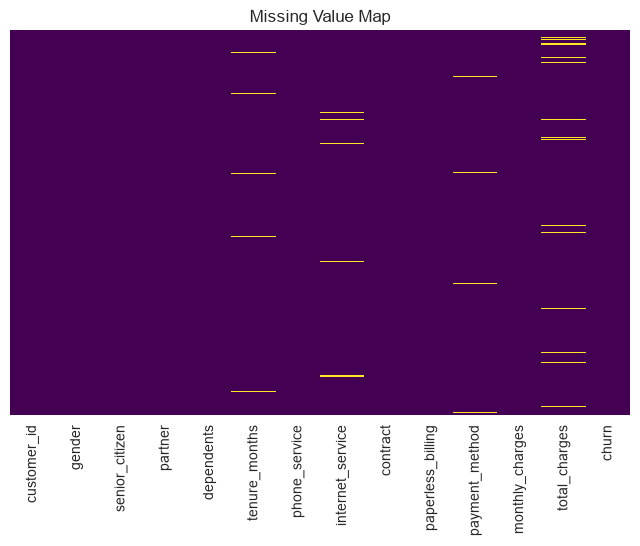

In [9]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Map')
plt.show()

`tenure_months`, `internet_service`, `payment_method`, and `total_charges` all have missing values, ranging from ~1% to ~3% of rows. The gaps look scattered rather than concentrated in a block, suggesting missingness is likely not tied to one specific data-collection batch — worth confirming further before choosing an imputation approach.


## 6. Identify Duplicates

In [10]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated customer_id values:", df['customer_id'].duplicated().sum())
df[df.duplicated(keep=False)].sort_values('customer_id').head(10)

Fully duplicated rows: 15
Duplicated customer_id values: 15


,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,internet_service,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
732,CUST-10049,Female,0,No,No,22.0,Yes,DSL,Month-to-month,Yes,Electronic check,88.60,1959.72,No
845,CUST-10049,Female,0,No,No,22.0,Yes,DSL,Month-to-month,Yes,Electronic check,88.60,1959.72,No
274,CUST-10142,Male,0,Yes,No,38.0,Yes,Fiber optic,One year,Yes,Electronic check,46.90,1762.33,No
488,CUST-10142,Male,0,Yes,No,38.0,Yes,Fiber optic,One year,Yes,Electronic check,46.90,1762.33,No
93,CUST-10242,Male,1,No,No,67.0,Yes,Fiber optic,One year,Yes,Mailed check,119.45,8031.71,No
801,CUST-10242,Male,1,No,No,67.0,Yes,Fiber optic,One year,Yes,Mailed check,119.45,8031.71,No
103,CUST-10262,Male,0,No,No,17.0,Yes,No,One year,No,Bank transfer,102.41,1722.17,Yes
768,CUST-10262,Male,0,No,No,17.0,Yes,No,One year,No,Bank transfer,102.41,1722.17,Yes
75,CUST-10318,Female,0,Yes,No,34.0,Yes,Fiber optic,Month-to-month,Yes,Mailed check,49.19,1675.96,Yes
810,CUST-10318,Female,0,Yes,No,34.0,Yes,Fiber optic,Month-to-month,Yes,Mailed check,49.19,1675.96,Yes


There are duplicate rows, and the duplicate count matches the duplicate `customer_id` count exactly — meaning the same customers appear twice with identical records, rather than different customers coincidentally sharing an ID. These should be removed in preprocessing.


## 7. Analyze Numerical Features

In [11]:
numeric_cols = ['tenure_months', 'monthly_charges', 'total_charges']
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure_months,1005.0,34.259701,21.137597,0.00,16.000,34.00,52.00,72.00
monthly_charges,1015.0,69.294039,30.125169,-97.93,44.395,70.09,94.37,119.45
total_charges,985.0,2360.987442,1883.592371,0.00,867.590,1849.21,3486.55,8354.36


In [12]:
print("Skewness:")
print(df[numeric_cols].skew())
print("\nKurtosis:")
print(df[numeric_cols].kurtosis())

Skewness:
tenure_months      0.068314
monthly_charges   -0.301960
total_charges      0.943583
dtype: float64

Kurtosis:
tenure_months     -1.214335
monthly_charges    0.288422
total_charges      0.167045
dtype: float64


In [13]:
print("Negative values check:")
for c in numeric_cols:
    print(f"  {c}: {(df[c] < 0).sum()} negative value(s), min = {df[c].min()}")

Negative values check:
  tenure_months: 0 negative value(s), min = 0.0
  monthly_charges: 3 negative value(s), min = -97.93
  total_charges: 0 negative value(s), min = 0.0


- `tenure_months` ranges 0–72 months, roughly symmetric (mean ≈ median ≈ 34).
- `monthly_charges` ranges up to ~119, but has a **minimum below zero** — a physically invalid reading, since a bill can't be negative. This needs correction before analysis/modeling.
- `total_charges` is right-skewed (skew ≈ 0.94) — expected, since it accumulates over tenure and a few long-standing customers pull the tail upward.


## 8. Analyze Categorical Features

In [14]:
cat_cols = ['gender', 'partner', 'dependents', 'phone_service', 'internet_service',
            'contract', 'paperless_billing', 'payment_method', 'churn']
for c in cat_cols:
    print(f"--- {c} ---")
    print(df[c].value_counts(dropna=False))
    print()

--- gender ---
gender
Female    498
Male      490
female      9
F           7
M           7
male        4
Name: count, dtype: int64

--- partner ---
partner
No     501
Yes    492
yes      7
Y        7
N        5
no       3
Name: count, dtype: int64

--- dependents ---
dependents
No     700
Yes    315
Name: count, dtype: int64

--- phone_service ---
phone_service
Yes    916
No      99
Name: count, dtype: int64

--- internet_service ---
internet_service
Fiber optic    431
DSL            389
No             175
NaN             20
Name: count, dtype: int64

--- contract ---
contract
Month-to-month    559
One year          249
Two year          207
Name: count, dtype: int64

--- paperless_billing ---
paperless_billing
Yes    604
No     386
N        8
yes      7
Y        5
no       5
Name: count, dtype: int64

--- payment_method ---
payment_method
Bank transfer       268
Mailed check        255
Credit card         242
Electronic check    235
NaN                  15
Name: count, dtype: int64



- `gender` and `partner` and `paperless_billing` each show **more distinct values than real categories** (e.g. `Yes`, `yes`, `Y` all mean the same thing) — an inconsistent-labeling problem, not real diversity in the data.
- `dependents`, `phone_service`, and `churn` are clean binary Yes/No fields.
- `internet_service` has three real categories (`DSL`, `Fiber optic`, `No`) plus missing values.
- `contract` has three tiers: `Month-to-month`, `One year`, `Two year`.
- `payment_method` has four methods plus missing values.


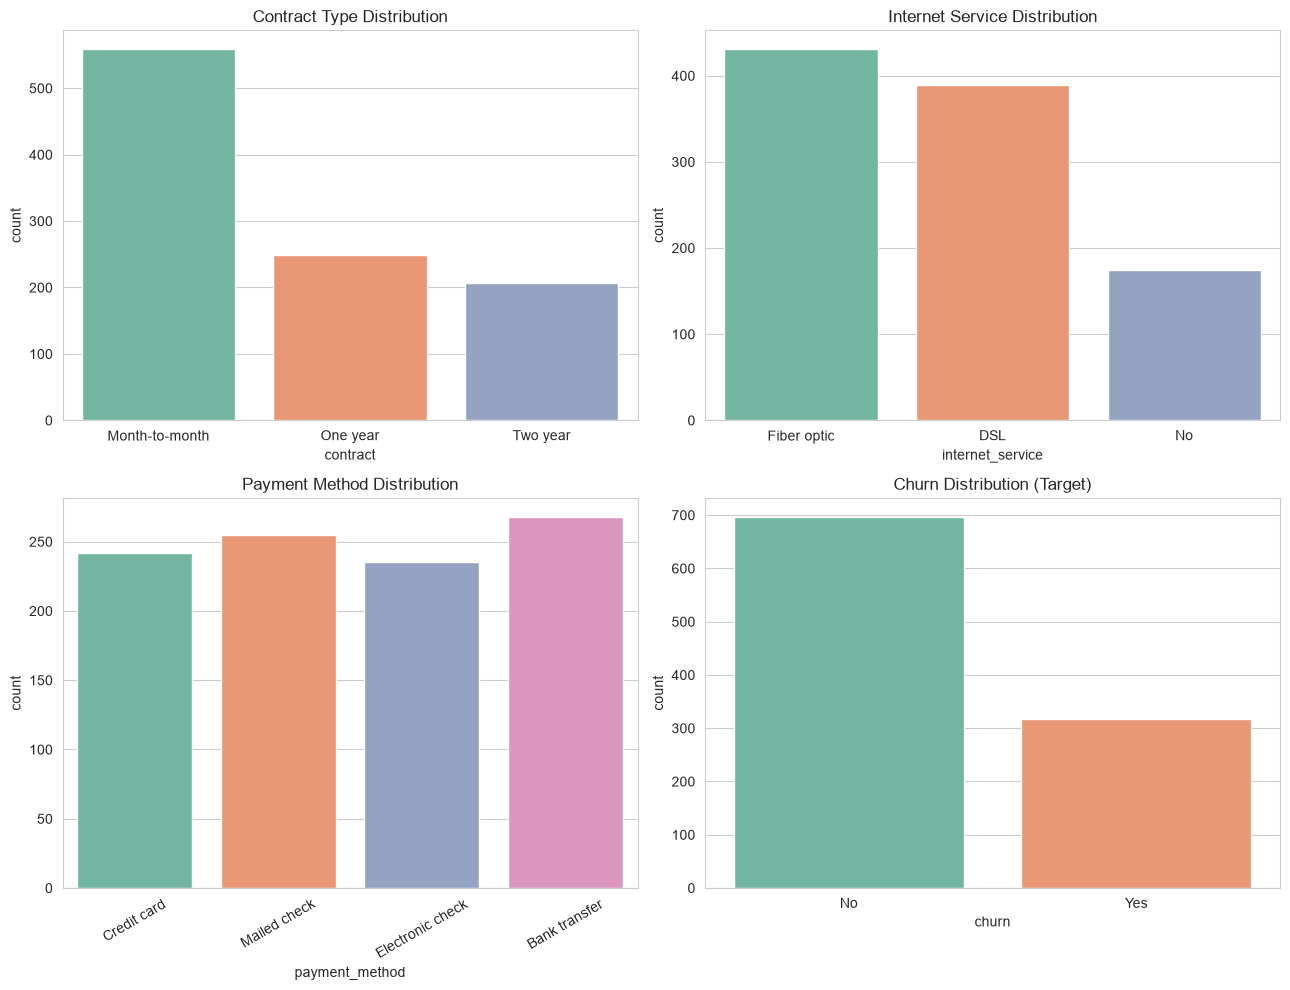

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
sns.countplot(data=df, x='contract', hue='contract', palette='Set2', legend=False, ax=axes[0,0])
axes[0,0].set_title('Contract Type Distribution')
sns.countplot(data=df, x='internet_service', hue='internet_service', palette='Set2', legend=False, ax=axes[0,1])
axes[0,1].set_title('Internet Service Distribution')
sns.countplot(data=df, x='payment_method', hue='payment_method', palette='Set2', legend=False, ax=axes[1,0])
axes[1,0].set_title('Payment Method Distribution')
axes[1,0].tick_params(axis='x', rotation=30)
sns.countplot(data=df, x='churn', hue='churn', palette='Set2', legend=False, ax=axes[1,1])
axes[1,1].set_title('Churn Distribution (Target)')
plt.tight_layout()
plt.show()

## 9. Detect Outliers

In [16]:
def iqr_bounds(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

for c in numeric_cols:
    lo, hi = iqr_bounds(df[c].dropna())
    n_out = df[(df[c] < lo) | (df[c] > hi)].shape[0]
    print(f"{c}: bounds=({lo:.2f}, {hi:.2f}) -> {n_out} outlier(s)")

tenure_months: bounds=(-38.00, 106.00) -> 0 outlier(s)
monthly_charges: bounds=(-30.57, 169.33) -> 2 outlier(s)
total_charges: bounds=(-3060.85, 7414.99) -> 12 outlier(s)


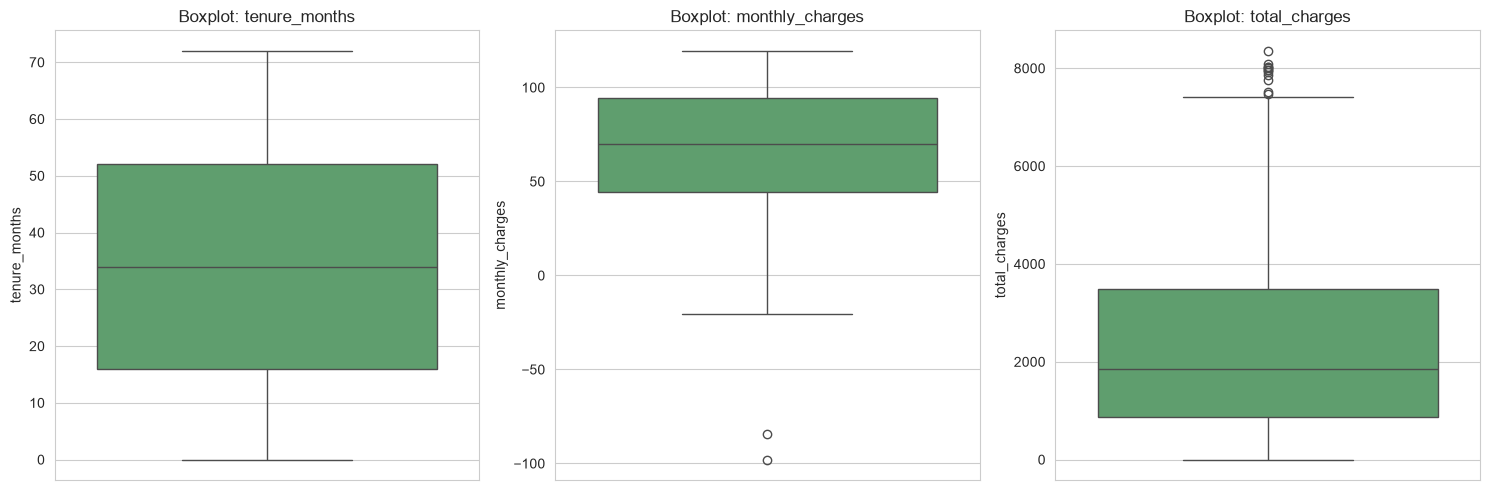

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, c in zip(axes, numeric_cols):
    sns.boxplot(y=df[c], ax=ax, color='#55A868')
    ax.set_title(f'Boxplot: {c}')
plt.tight_layout()
plt.show()

- The `monthly_charges` outliers are the same invalid negative values flagged earlier — not genuine extremes.
- `total_charges` shows a set of high-end outliers, consistent with its right skew; these look like plausible long-tenure, high-value customers rather than errors, but warrant review.
- `tenure_months` has no flagged outliers — a clean, well-behaved distribution.


## 10. Analyze Distributions

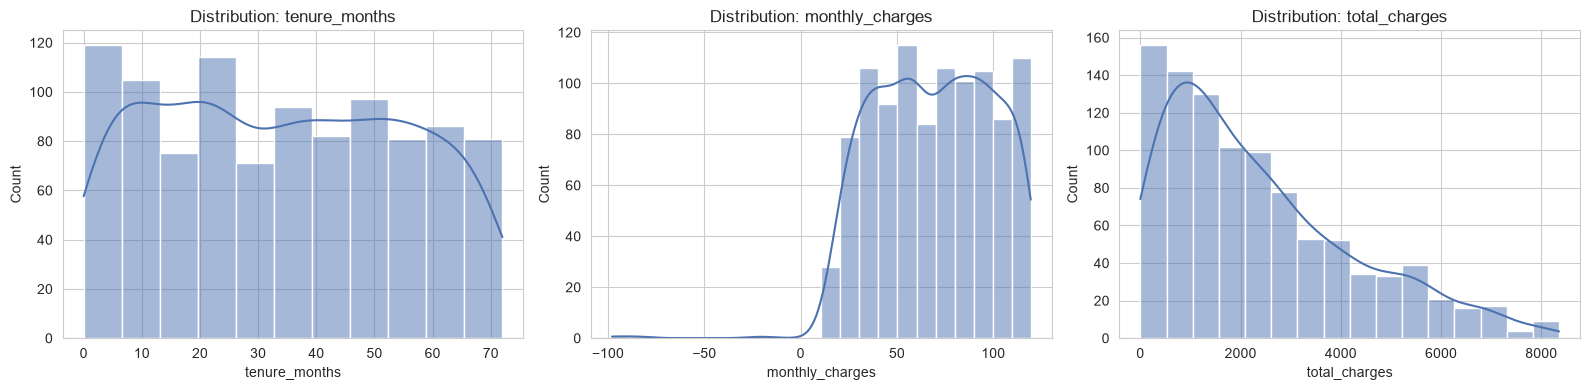

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, c in zip(axes, numeric_cols):
    sns.histplot(df[c].dropna(), kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f'Distribution: {c}')
plt.tight_layout()
plt.show()

- `tenure_months` is roughly uniform/symmetric across 0–72 months — no strong concentration at any tenure length.
- `monthly_charges` is fairly evenly spread with a slight left skew (again partly due to invalid negatives).
- `total_charges` is clearly right-skewed with a long tail — a log or square-root transform would likely make it more model-friendly for linear methods.


## 11. Analyze Correlations

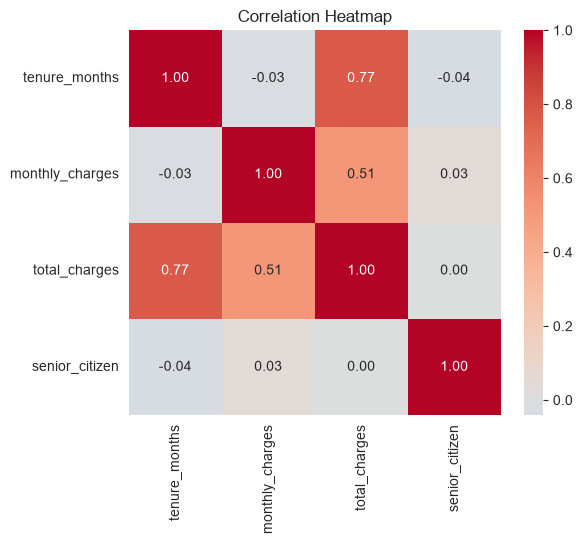

,tenure_months,monthly_charges,total_charges,senior_citizen
tenure_months,1.000000,-0.028202,0.766786,-0.041297
monthly_charges,-0.028202,1.000000,0.511545,0.033465
total_charges,0.766786,0.511545,1.000000,0.003306
senior_citizen,-0.041297,0.033465,0.003306,1.000000


In [19]:
corr = df[numeric_cols + ['senior_citizen']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()
corr

- `tenure_months` and `total_charges` are strongly correlated (~0.77) — unsurprising, since total billed amount naturally grows with time as a customer.
- `monthly_charges` and `total_charges` are moderately correlated (~0.51).
- `tenure_months` and `monthly_charges` are essentially independent (~-0.03).
- `senior_citizen` shows no meaningful linear relationship with the numeric billing/tenure features.

This suggests `total_charges` is largely a *derived* quantity (tenure × monthly rate, roughly) rather than new independent information.


## 12–13. Meaningful Visualizations & Important Patterns

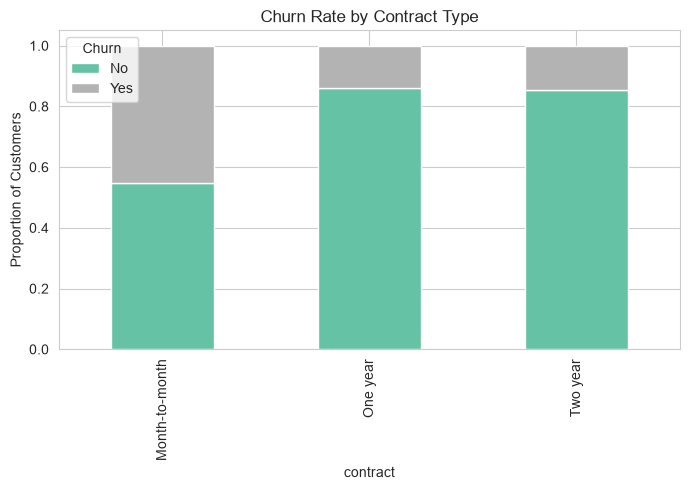

churn,No,Yes
contract,,
Month-to-month,0.547406,0.452594
One year,0.859438,0.140562
Two year,0.855072,0.144928


In [20]:
churn_by_contract = df.groupby('contract')['churn'].value_counts(normalize=True).unstack().fillna(0)
churn_by_contract.plot(kind='bar', stacked=True, figsize=(7,5), colormap='Set2')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Proportion of Customers')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()
churn_by_contract


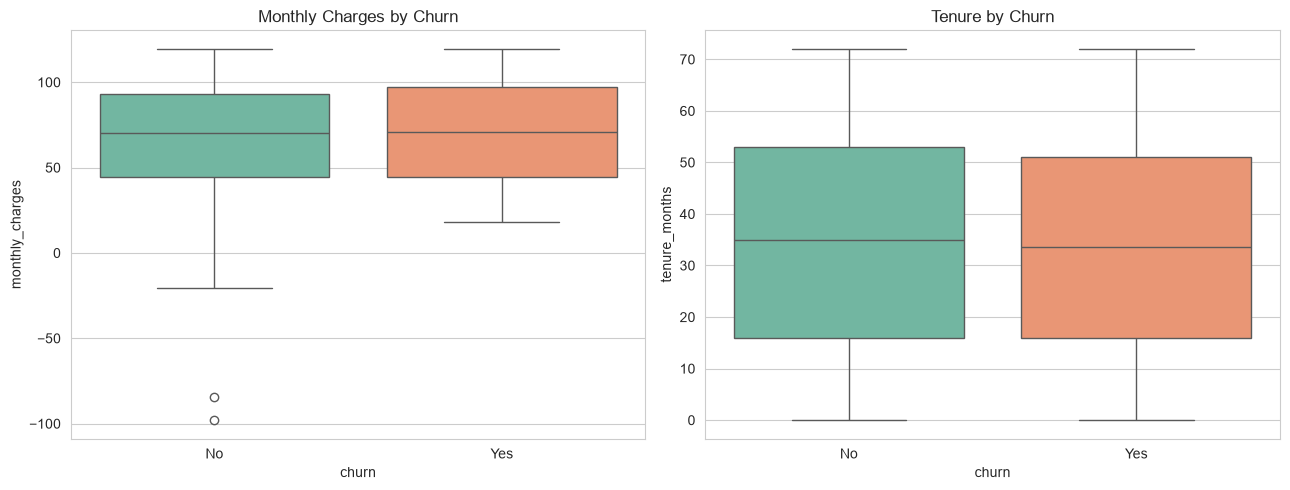

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df, x='churn', y='monthly_charges', hue='churn', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Monthly Charges by Churn')
sns.boxplot(data=df, x='churn', y='tenure_months', hue='churn', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Tenure by Churn')
plt.tight_layout()
plt.show()

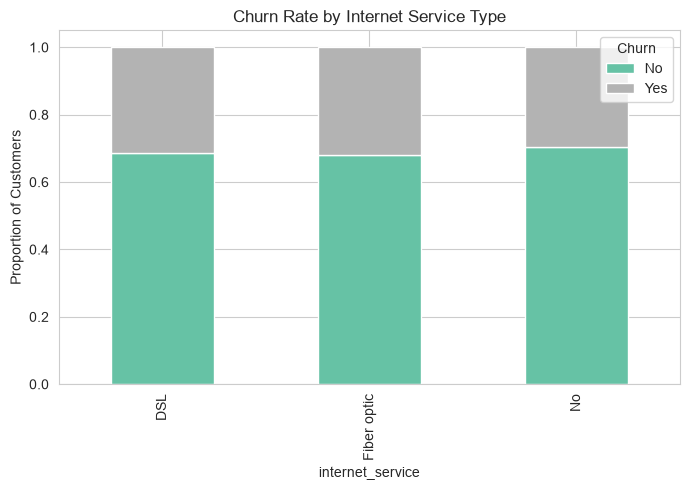

churn,No,Yes
internet_service,,
DSL,0.686375,0.313625
Fiber optic,0.679814,0.320186
No,0.702857,0.297143


In [22]:
churn_by_internet = df.groupby('internet_service')['churn'].value_counts(normalize=True).unstack().fillna(0)
churn_by_internet.plot(kind='bar', stacked=True, figsize=(7,5), colormap='Set2')
plt.title('Churn Rate by Internet Service Type')
plt.ylabel('Proportion of Customers')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()
churn_by_internet

**Key patterns identified:**

1. **Contract type is the single strongest churn driver visible in the data.** Month-to-month customers churn at roughly **3x the rate** of one-year or two-year contract holders (~45% vs ~14%).
2. **Churners tend to have shorter tenure and higher monthly charges** than customers who stay — consistent with the idea that newer, higher-paying, flexible-contract customers are the most flight-risk segment.
3. **Fiber optic internet customers churn more than DSL or no-internet customers**, which may point to price sensitivity, service-quality issues, or stronger competition in that segment.
4. Overall churn rate is about **31%**, a moderate class imbalance to keep in mind for any predictive modeling.


## 14. Business Insights

- **Retention risk is concentrated in month-to-month, fiber-optic, short-tenure, higher-bill customers.** This is a clearly identifiable at-risk segment the business could target proactively (e.g. loyalty offers, contract-upgrade incentives) rather than treating all customers uniformly.
- **Long-term contracts strongly correlate with retention.** Incentivizing customers to move from month-to-month to annual or two-year contracts (via discounts or bundled perks) could materially reduce churn, since the churn gap between month-to-month and longer contracts is large and consistent.
- **Fiber optic churn is notably higher than other internet types**, which may signal a service, pricing, or competitive issue specific to that product line worth investigating with the product/network team.
- **Billing amount matters:** churners skew toward higher monthly charges, suggesting price sensitivity or perceived value gaps — a pricing or value-communication review for high-bill customers may help.
- The ~31% churn rate is high enough that even modest improvements in the highest-risk segment (month-to-month, fiber, short tenure) could produce a measurable reduction in overall churn.


## 15. Recommendations for the Next Preprocessing Stage

- **Missing-value treatment:** Impute `tenure_months` and `total_charges` (their strong correlation with each other can help cross-impute); impute or flag missing `internet_service` and `payment_method` (mode or an explicit "Unknown" category).
- **Duplicate removal:** Drop the fully duplicated `customer_id` rows identified in Step 6.
- **Invalid-value correction:** Investigate and fix the negative `monthly_charges` entries before any further numeric analysis or modeling.
- **Categorical normalization:** Standardize inconsistent labels in `gender`, `partner`, and `paperless_billing` (casing/abbreviations) so each field has its true number of categories.
- **Encoding:** One-hot or label encode all categorical predictors; binary-encode the `churn` target.
- **Scaling:** Standardize or min-max scale `tenure_months`, `monthly_charges`, and `total_charges` for scale-sensitive models.
- **Outlier handling:** Decide on capping/winsorizing the high-end `total_charges` outliers once the negative `monthly_charges` values are fixed (they otherwise appear genuine, not erroneous).
- **Feature transformation:** Consider a log transform on `total_charges` to reduce right-skew for linear models.
- **Feature engineering:** Consider a tenure bucket (e.g. 0–12 / 13–36 / 37+ months) and an average-charge-per-month ratio; evaluate dropping or transforming `total_charges` given its correlation with `tenure_months` × `monthly_charges`.
- **Data type correction:** Cast `senior_citizen` to boolean/category, `tenure_months` to integer post-imputation, and remaining categorical columns to pandas `category` dtype.
- **Class imbalance:** Use stratified train/test splitting and/or class weighting given the ~69/31 churn split when this dataset is used for modeling.
- **Drop non-predictive fields:** Exclude `customer_id` from any modeling feature set.
